In [1]:
from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from matplotlib.patches import Patch
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs("charts", exist_ok=True)

# Color palette
BLUE   = '#2563EB'
GREEN  = '#16A34A'
ORANGE = '#EA580C'
PURPLE = '#7C3AED'
TEAL   = '#0891B2'

# Plot styling
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8FAFC',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print("All libraries ready!")

All libraries ready!


In [3]:
#Task 1: Load & Explore Data
# Load dataset
df = pd.read_csv("Housing.csv")

In [4]:
# First 10 rows
print("📄 First 10 rows:")
display(df.head(10))

📄 First 10 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [6]:
# Shape
print(f"\n Shape : {df.shape[0]} rows × {df.shape[1]} columns")


 Shape : 545 rows × 13 columns


In [7]:
# Target vs Features
print(f"\n Target column   : price")
features = [c for c in df.columns if c != 'price']
print(f" Feature columns : {features}")


 Target column   : price
 Feature columns : ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [8]:
# Missing values
print(f"\n🔍 Missing values:")
print(df.isnull().sum())


🔍 Missing values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [9]:
# Basic statistics
print(f"\n📊 Basic statistics:")
display(df.describe())


📊 Basic statistics:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [12]:
#Task 2: Data Cleaning
# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f" Duplicates removed : {before - len(df)}")
print(f" Rows remaining     : {len(df)}")

 Duplicates removed : 0
 Rows remaining     : 545


In [13]:
# Fill missing values if any
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"   Filled '{col}' with median.")
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"   Filled '{col}' with mode.")
print("No missing values — dataset is clean.")

No missing values — dataset is clean.


In [14]:
# Encode binary yes/no → 0/1
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})
    print(f"'{col}' encoded (yes=1, no=0)")

'mainroad' encoded (yes=1, no=0)
'guestroom' encoded (yes=1, no=0)
'basement' encoded (yes=1, no=0)
'hotwaterheating' encoded (yes=1, no=0)
'airconditioning' encoded (yes=1, no=0)
'prefarea' encoded (yes=1, no=0)


In [22]:
if 'furnishingstatus' in df.columns:
    df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
    print(f"'furnishingstatus' encoded.")
else:
    print("'furnishingstatus' column not found, likely already encoded or removed.")

print(f"\n Final shape: {df.shape}")
display(df.head())

'furnishingstatus' column not found, likely already encoded or removed.

 Final shape: (545, 14)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [23]:
#Task 3: Model Building
X = df.drop('price', axis=1)
y = df['price']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f" Training samples : {X_train.shape[0]}")
print(f" Test samples     : {X_test.shape[0]}")


 Training samples : 436
 Test samples     : 109


In [24]:
# ── Model 1: Linear Regression ──
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"\nLINEAR REGRESSION")
print(f"   MAE  : ₹{mae_lr:,.0f}")
print(f"   RMSE : ₹{rmse_lr:,.0f}")
print(f"   R²   : {r2_lr:.4f}  ({r2_lr*100:.1f}% variance explained)")



LINEAR REGRESSION
   MAE  : ₹970,043
   RMSE : ₹1,324,507
   R²   : 0.6529  (65.3% variance explained)


In [25]:
# ── Model 2: Random Forest ──
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"\nRANDOM FOREST")
print(f"   MAE  : ₹{mae_rf:,.0f}")
print(f"   RMSE : ₹{rmse_rf:,.0f}")
print(f"   R²   : {r2_rf:.4f}  ({r2_rf*100:.1f}% variance explained)")



RANDOM FOREST
   MAE  : ₹1,014,947
   RMSE : ₹1,399,769
   R²   : 0.6124  (61.2% variance explained)


In [26]:
# Comparison table
comparison = pd.DataFrame({
    'Model' : ['Linear Regression', 'Random Forest'],
    'MAE'   : [f'₹{mae_lr:,.0f}',  f'₹{mae_rf:,.0f}'],
    'RMSE'  : [f'₹{rmse_lr:,.0f}', f'₹{rmse_rf:,.0f}'],
    'R²'    : [f'{r2_lr:.4f}',     f'{r2_rf:.4f}'],
})
print("\n Model Comparison:")
display(comparison)

winner = "Linear Regression" if r2_lr >= r2_rf else "Random Forest"
print(f"\n Better model: {winner}")



 Model Comparison:


,Model,MAE,RMSE,R²
0,Linear Regression,"₹970,043","₹1,324,507",0.6529
1,Random Forest,"₹1,014,947","₹1,399,769",0.6124



 Better model: Linear Regression


In [29]:
# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(f"\n Feature Importances:")
for feat, imp in feat_imp.items():
    bar = "█" * int(imp * 50)
    print(f"   {feat:<36} {bar} {imp:.3f}")


 Feature Importances:
   area                                 ███████████████████████ 0.468
   bathrooms                            ███████ 0.153
   airconditioning                      ███ 0.060
   parking                              ██ 0.058
   stories                              ██ 0.057
   bedrooms                             ██ 0.048
   furnishingstatus_unfurnished         █ 0.037
   basement                             █ 0.032
   prefarea                             █ 0.028
   hotwaterheating                       0.018
   guestroom                             0.018
   furnishingstatus_semi-furnished       0.013
   mainroad                              0.010


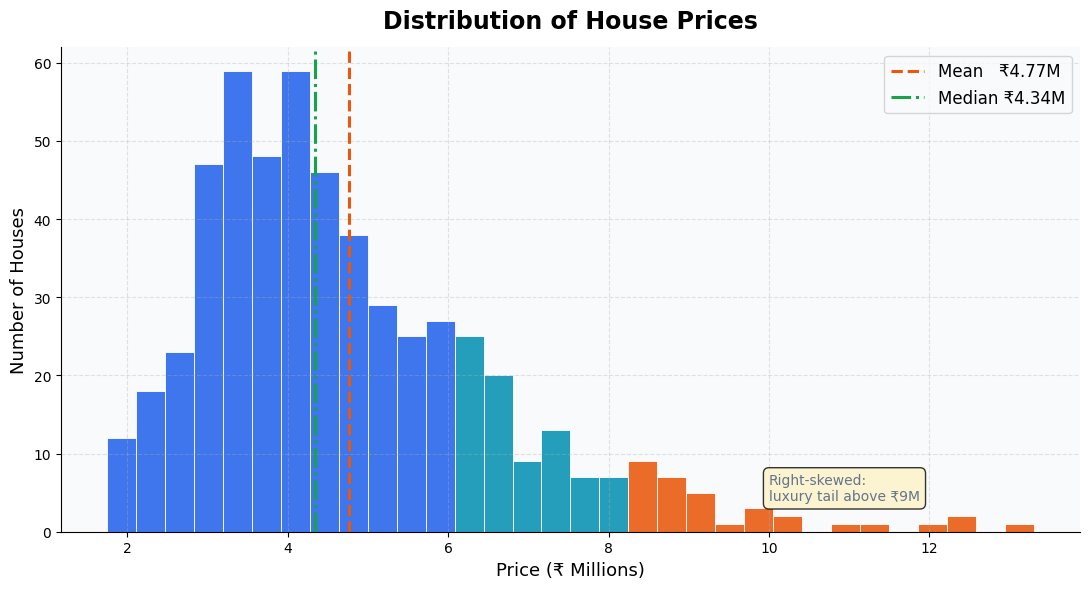

Chart 1 saved!


In [30]:
#Task 4: Chart 1 — Price Distribution
fig, ax = plt.subplots(figsize=(11, 6))

n, bins, patches = ax.hist(
    df['price'] / 1e6, bins=32,
    color=BLUE, edgecolor='white', linewidth=0.7, alpha=0.88
)
for patch, b in zip(patches, bins):
    if b > 8:
        patch.set_facecolor(ORANGE)
    elif b > 6:
        patch.set_facecolor(TEAL)

mean_val   = df['price'].mean() / 1e6
median_val = df['price'].median() / 1e6

ax.axvline(mean_val,   color=ORANGE, linewidth=2.2, linestyle='--',
           label=f'Mean   ₹{mean_val:.2f}M')
ax.axvline(median_val, color=GREEN,  linewidth=2.2, linestyle='-.',
           label=f'Median ₹{median_val:.2f}M')

ax.set_title('Distribution of House Prices', fontsize=17, fontweight='bold', pad=14)
ax.set_xlabel('Price (₹ Millions)', fontsize=13)
ax.set_ylabel('Number of Houses', fontsize=13)
ax.legend(fontsize=12)
ax.annotate('Right-skewed:\nluxury tail above ₹9M',
            xy=(10, 4), fontsize=10, color='#64748B',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FEF3C7', alpha=0.8))

plt.tight_layout()
plt.savefig("charts/chart1_price_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

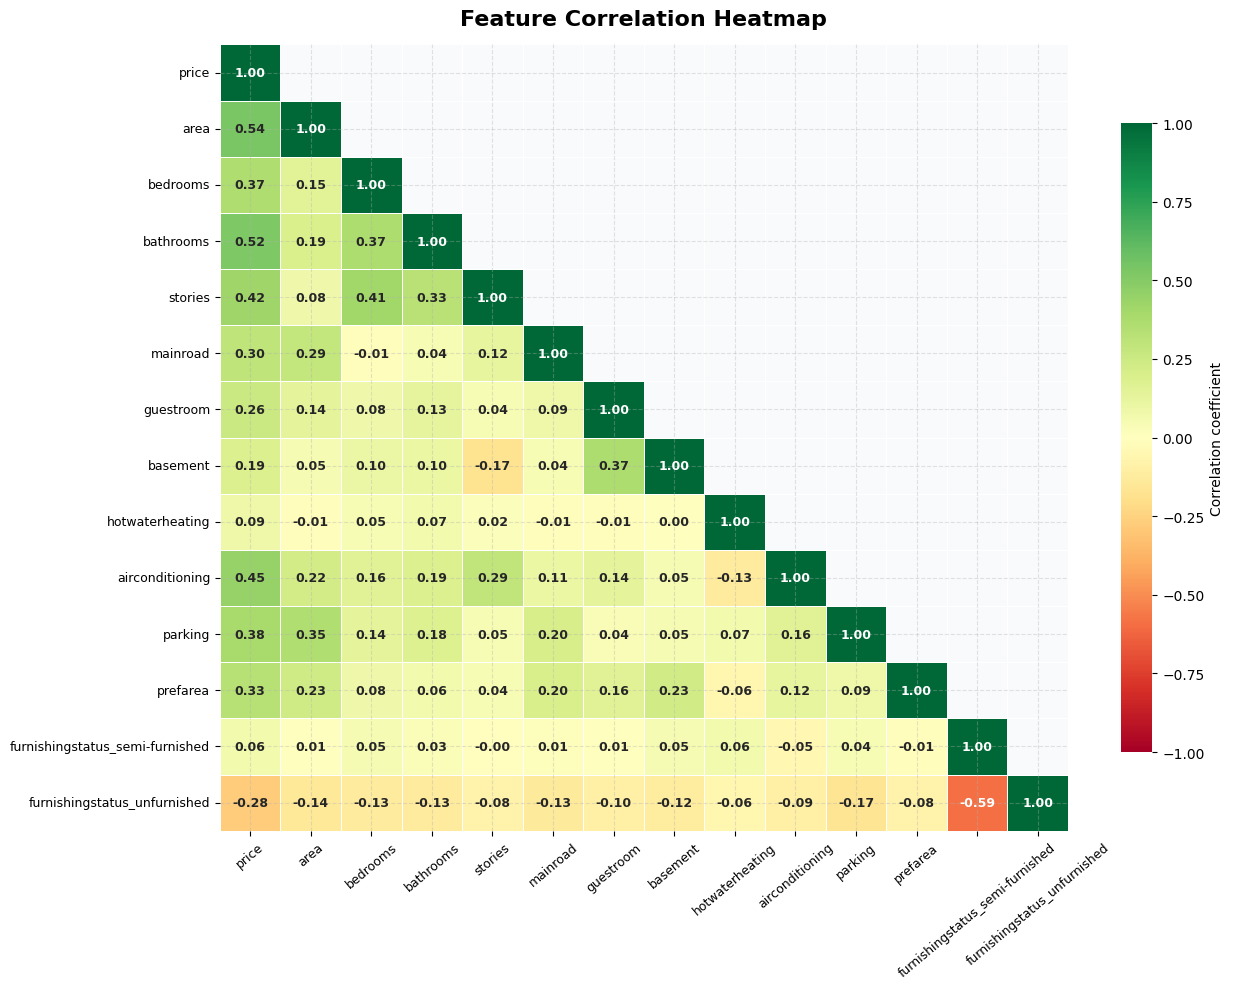

Chart 2 saved!


In [31]:
#Task 4: Chart 2 — Correlation Heatmap
fig, ax = plt.subplots(figsize=(13, 10))

corr = df.corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    linewidths=0.5, linecolor='white',
    ax=ax, annot_kws={'size': 9, 'weight': 'bold'},
    vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation coefficient'}
)
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=40, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig("charts/chart2_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

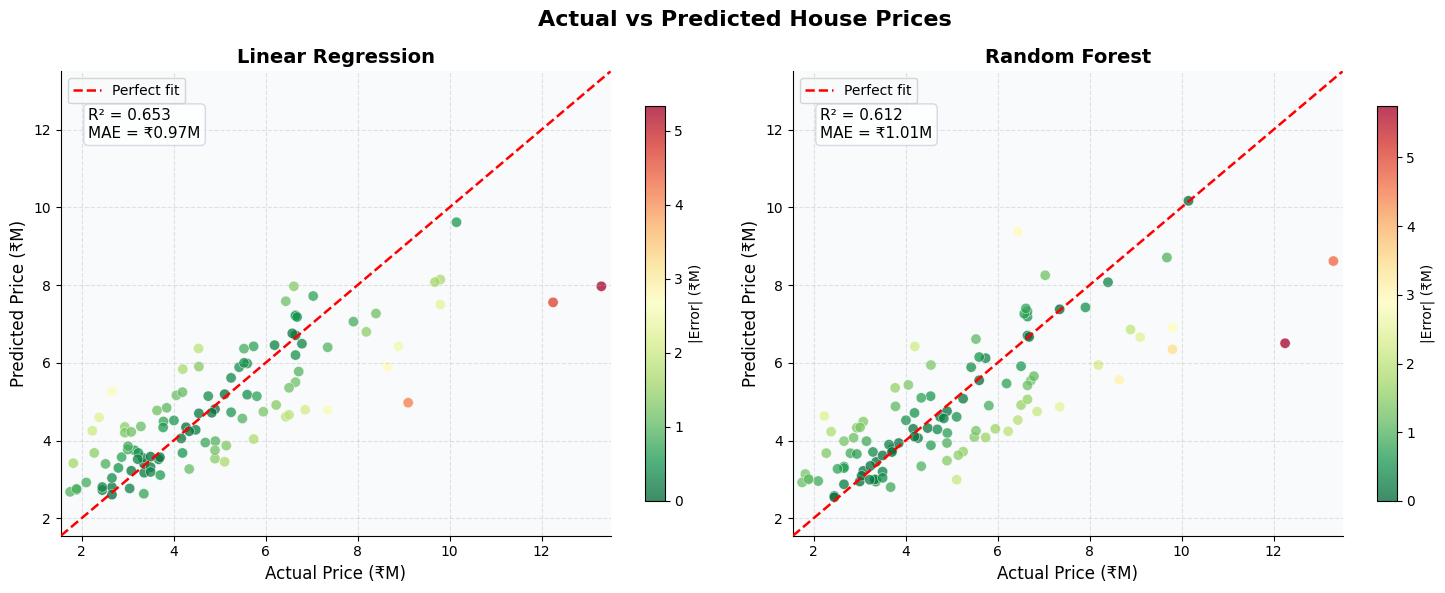

Chart 3 saved!


In [32]:
#Task 4: Chart 3 — Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, y_pred, label, color, r2, mae in [
    (axes[0], y_pred_lr, 'Linear Regression', BLUE,   r2_lr, mae_lr),
    (axes[1], y_pred_rf, 'Random Forest',     PURPLE, r2_rf, mae_rf),
]:
    actual = y_test.values / 1e6
    pred   = y_pred / 1e6
    errors = np.abs(actual - pred)

    sc = ax.scatter(actual, pred, c=errors, cmap='RdYlGn_r',
                    alpha=0.75, s=55, edgecolors='white', linewidth=0.4,
                    vmin=0, vmax=errors.max())

    lims = [min(actual.min(), pred.min()) - 0.2,
            max(actual.max(), pred.max()) + 0.2]
    ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect fit', zorder=5)
    ax.set_xlim(lims); ax.set_ylim(lims)

    plt.colorbar(sc, ax=ax, label='|Error| (₹M)', shrink=0.85)
    ax.set_title(label, fontsize=14, fontweight='bold')
    ax.set_xlabel('Actual Price (₹M)', fontsize=12)
    ax.set_ylabel('Predicted Price (₹M)', fontsize=12)
    ax.legend(fontsize=10)
    ax.text(0.05, 0.92, f'R² = {r2:.3f}\nMAE = ₹{mae/1e6:.2f}M',
            transform=ax.transAxes, fontsize=11, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='#CBD5E1'))

fig.suptitle('Actual vs Predicted House Prices', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("charts/chart3_actual_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

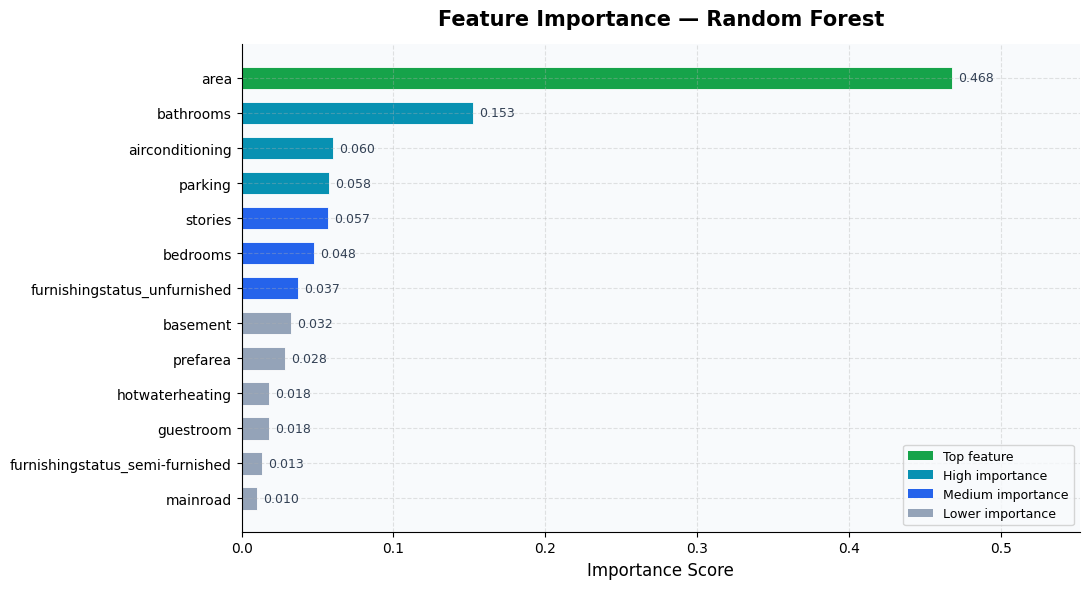

Chart 4 saved!


In [33]:
#Chart 4 — Feature Importance
fig, ax = plt.subplots(figsize=(11, 6))

fi_sorted  = feat_imp.sort_values()
bar_colors = [
    GREEN     if v == fi_sorted.max()          else
    TEAL      if v >= fi_sorted.quantile(0.75) else
    BLUE      if v >= fi_sorted.median()       else
    '#94A3B8'
    for v in fi_sorted.values
]

bars = ax.barh(fi_sorted.index, fi_sorted.values,
               color=bar_colors, edgecolor='white', linewidth=0.6, height=0.65)

for bar, val in zip(bars, fi_sorted.values):
    ax.text(val + 0.004, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9, color='#334155')

ax.set_title('Feature Importance — Random Forest', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_xlim(0, fi_sorted.max() * 1.18)

legend_elements = [
    Patch(facecolor=GREEN,     label='Top feature'),
    Patch(facecolor=TEAL,      label='High importance'),
    Patch(facecolor=BLUE,      label='Medium importance'),
    Patch(facecolor='#94A3B8', label='Lower importance'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig("charts/chart4_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

In [34]:
#Task 5: Summary & Download All Files
# Print summary
summary = f"""

HOUSE PRICE PREDICTION — SUMMARY REPORT

DATASET
  Records    : {len(df)} rows × {df.shape[1]} columns
  Price range: ₹{df['price'].min()/1e6:.2f}M – ₹{df['price'].max()/1e6:.2f}M
  Mean price : ₹{df['price'].mean()/1e6:.2f}M  |  Median: ₹{df['price'].median()/1e6:.2f}M

MODEL PERFORMANCE
  Metric       Linear Regression     Random Forest
  ──────────── ───────────────────── ─────────────────────
  MAE          ₹{mae_lr:>12,.0f}    ₹{mae_rf:>12,.0f}
  RMSE         ₹{rmse_lr:>12,.0f}   ₹{rmse_rf:>12,.0f}
  R² Score     {r2_lr:>18.4f}    {r2_rf:>16.4f}
  Winner  →    {winner}

TOP FEATURES (Random Forest Importance)
{chr(10).join(f"  {i+1}. {feat:<35} {imp:.3f} ({imp*100:.1f}%)"
              for i, (feat, imp) in enumerate(feat_imp.items()))}

INSIGHTS
  Q1. Which features influence price most?
      Area is the #1 driver (~{feat_imp['area']*100:.0f}%), followed by bathrooms (~{feat_imp['bathrooms']*100:.0f}%),
      AC, parking, and stories. These 5 explain 80%+ of price variation.

  Q2. How accurate was the model?
      Linear Regression explained {r2_lr*100:.1f}% of price variation (R²={r2_lr:.3f})
      with an average error of ₹{mae_lr/1e5:.1f} lakh per prediction.

  Q3. What surprised you?
      Bedrooms matter LESS than bathrooms — buyers value amenities
      over room count. Hot water heating also signals luxury strongly.
      Prices are right-skewed with a long luxury tail above ₹9M.

  Q4. Business recommendation:
      Price listings using area + bathrooms + AC + parking + stories.
      For sellers renovating, adding a bathroom or AC gives the best
      ROI. Feature these prominently in listings over bedroom count.
"""

print(summary)

# Save summary
with open("summary.txt", "w", encoding="utf-8") as f:
    f.write(summary)
print("summary.txt saved!")

# ── Download everything ──────────────────────────────────────────
import zipfile
from google.colab import files

with zipfile.ZipFile("HousePricePrediction_Output.zip", "w") as zf:
    zf.write("summary.txt")
    for chart in os.listdir("charts"):
        zf.write(f"charts/{chart}")

files.download("HousePricePrediction_Output.zip")
print("ZIP downloaded to your computer!")



HOUSE PRICE PREDICTION — SUMMARY REPORT

DATASET
  Records    : 545 rows × 14 columns
  Price range: ₹1.75M – ₹13.30M
  Mean price : ₹4.77M  |  Median: ₹4.34M

MODEL PERFORMANCE
  Metric       Linear Regression     Random Forest
  ──────────── ───────────────────── ─────────────────────
  MAE          ₹     970,043    ₹   1,014,947
  RMSE         ₹   1,324,507   ₹   1,399,769
  R² Score                 0.6529              0.6124
  Winner  →    Linear Regression

TOP FEATURES (Random Forest Importance)
  1. area                                0.468 (46.8%)
  2. bathrooms                           0.153 (15.3%)
  3. airconditioning                     0.060 (6.0%)
  4. parking                             0.058 (5.8%)
  5. stories                             0.057 (5.7%)
  6. bedrooms                            0.048 (4.8%)
  7. furnishingstatus_unfurnished        0.037 (3.7%)
  8. basement                            0.032 (3.2%)
  9. prefarea                            0.028 (2.8%)
  1

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ZIP downloaded to your computer!
